<a href="https://colab.research.google.com/github/Himanshu-rana-IITK/Himanshu-rana-IITK/blob/main/AMEX_Draft_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer

from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

In [2]:
df = pd.read_csv("/content/amex1.csv")

print(df.shape)

df.head()

(190647, 24)


,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23
0,0,0.000000,0.0,1.0,98615.44,5620.938246,NaN,NaN,NaN,NaN,NaN,0.036093,4.0,0.0,0.0,0.0,49.280210,1960.0,1900.0,2.0,1.0,0.0,2.0,NaN
1,1,0.000000,0.0,0.0,21241.06,10196.878460,13865.4026,425.04840,27.9986,0.000,494.8428,0.000000,58.0,3.0,196.0,5.0,63.759364,34300.0,34650.0,3.0,2.0,163620.0,3.0,NaN
2,2,1224.690475,0.0,1.0,NaN,16.160000,NaN,NaN,NaN,NaN,NaN,0.182310,22.0,0.0,0.0,0.0,19.646836,NaN,NaN,1.0,1.0,NaN,9.0,NaN
3,3,0.000000,1.0,0.0,NaN,1635.316863,3231.1968,-269.15308,0.0000,0.000,48.5520,0.000040,NaN,0.0,0.0,0.0,9.143074,12348.0,12474.0,2.0,1.0,NaN,5.0,NaN
4,4,3824.366700,0.0,0.0,7140.87,5007.271790,4064.2152,16079.35060,377.9055,556.974,5354.3280,0.000253,3.0,0.0,0.0,11.0,63.759364,3672.0,3528.0,3.0,1.0,68640.0,0.0,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190647 entries, 0 to 190646
Data columns (total 24 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      190647 non-null  int64  
 1   f1      190646 non-null  float64
 2   f2      190646 non-null  float64
 3   f3      190646 non-null  float64
 4   f4      92640 non-null   float64
 5   f5      188179 non-null  float64
 6   f6      146527 non-null  float64
 7   f7      146527 non-null  float64
 8   f8      146527 non-null  float64
 9   f9      146527 non-null  float64
 10  f10     146527 non-null  float64
 11  f11     189657 non-null  float64
 12  f12     181293 non-null  float64
 13  f13     185397 non-null  float64
 14  f14     185397 non-null  float64
 15  f15     185397 non-null  float64
 16  f16     185397 non-null  float64
 17  f17     79051 non-null   float64
 18  f18     72563 non-null   float64
 19  f19     190635 non-null  float64
 20  f20     190603 non-null  float64
 21  f21     92

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,190647.0,95322.100002,55035.036836,0.000000,47660.500000,95322.000000,142983.500000,190645.000000
f1,190646.0,2461.866393,4801.211856,0.000000,0.000000,0.000000,2427.402165,17967.726330
f2,190646.0,0.174381,0.379438,0.000000,0.000000,0.000000,0.000000,1.000000
f3,190646.0,0.108410,0.310899,0.000000,0.000000,0.000000,0.000000,1.000000
f4,92640.0,127050.861466,184162.195836,2.000000,8004.465000,50475.450000,150926.812500,697899.350000
f5,188179.0,3457.101367,3710.725970,0.000000,661.760294,2156.503691,4899.454337,13596.279900
f6,146527.0,10038.990135,14000.000382,0.000000,634.730100,4023.193600,12895.298650,52198.432000
f7,146527.0,30814.701013,39469.676978,-274.646000,3351.577850,14349.973400,41351.821450,146700.554000
f8,146527.0,1526.155949,2522.163067,0.000000,0.000000,305.543700,1785.446700,9419.874000
f9,146527.0,1657.743742,2875.347671,0.000000,0.000000,265.419000,1827.884450,10828.994000


In [5]:
missing = pd.DataFrame(df.isnull().sum(),columns=["Missing"])

missing["Percentage"] = 100*missing["Missing"]/len(df)

missing.sort_values("Percentage",ascending=False)

,Missing,Percentage
f23,167343,87.776362
f18,118084,61.938557
f17,111596,58.535408
f4,98007,51.407575
f21,98007,51.407575
f6,44120,23.142247
f7,44120,23.142247
f8,44120,23.142247
f10,44120,23.142247
f9,44120,23.142247


In [6]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


In [7]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical :",len(num_cols))
print("Categorical :",len(cat_cols))

Numerical : 24
Categorical : 0


In [8]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

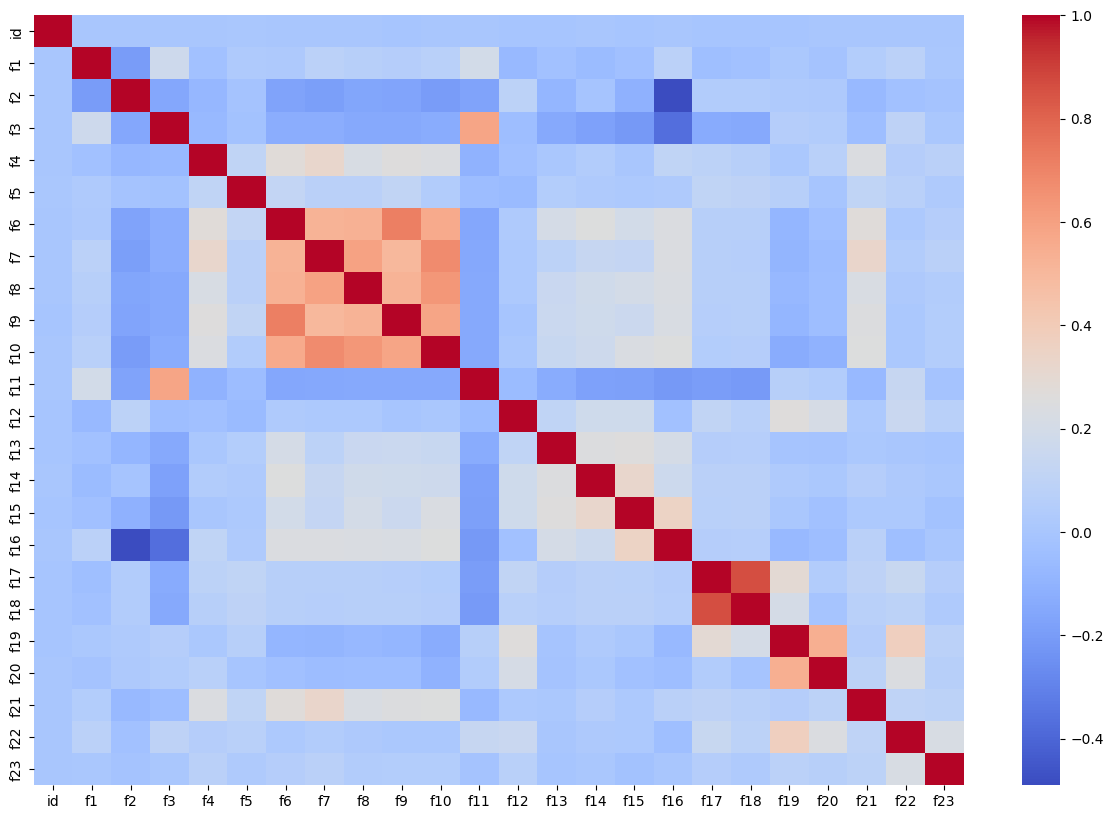

In [10]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(),cmap="coolwarm")

plt.show()

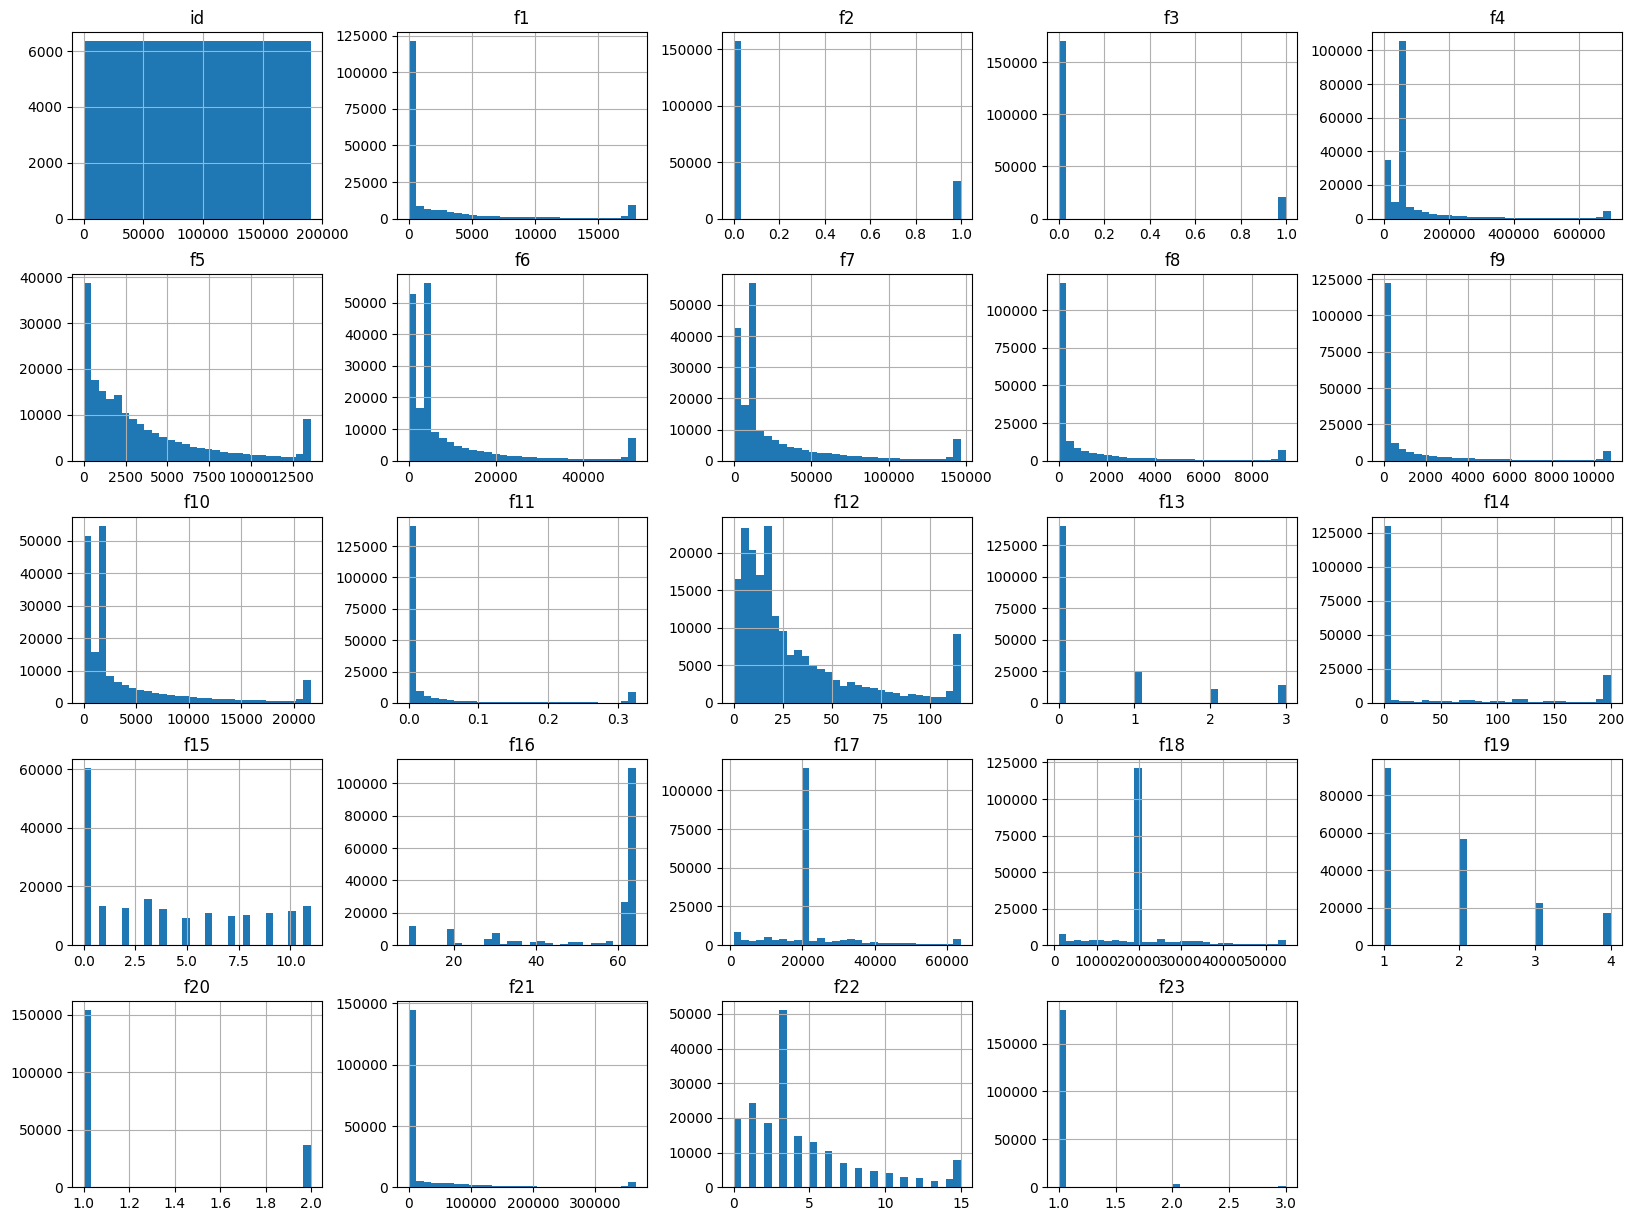

In [11]:
df[num_cols].hist(
    figsize=(20,15),
    bins=30
)

plt.show()

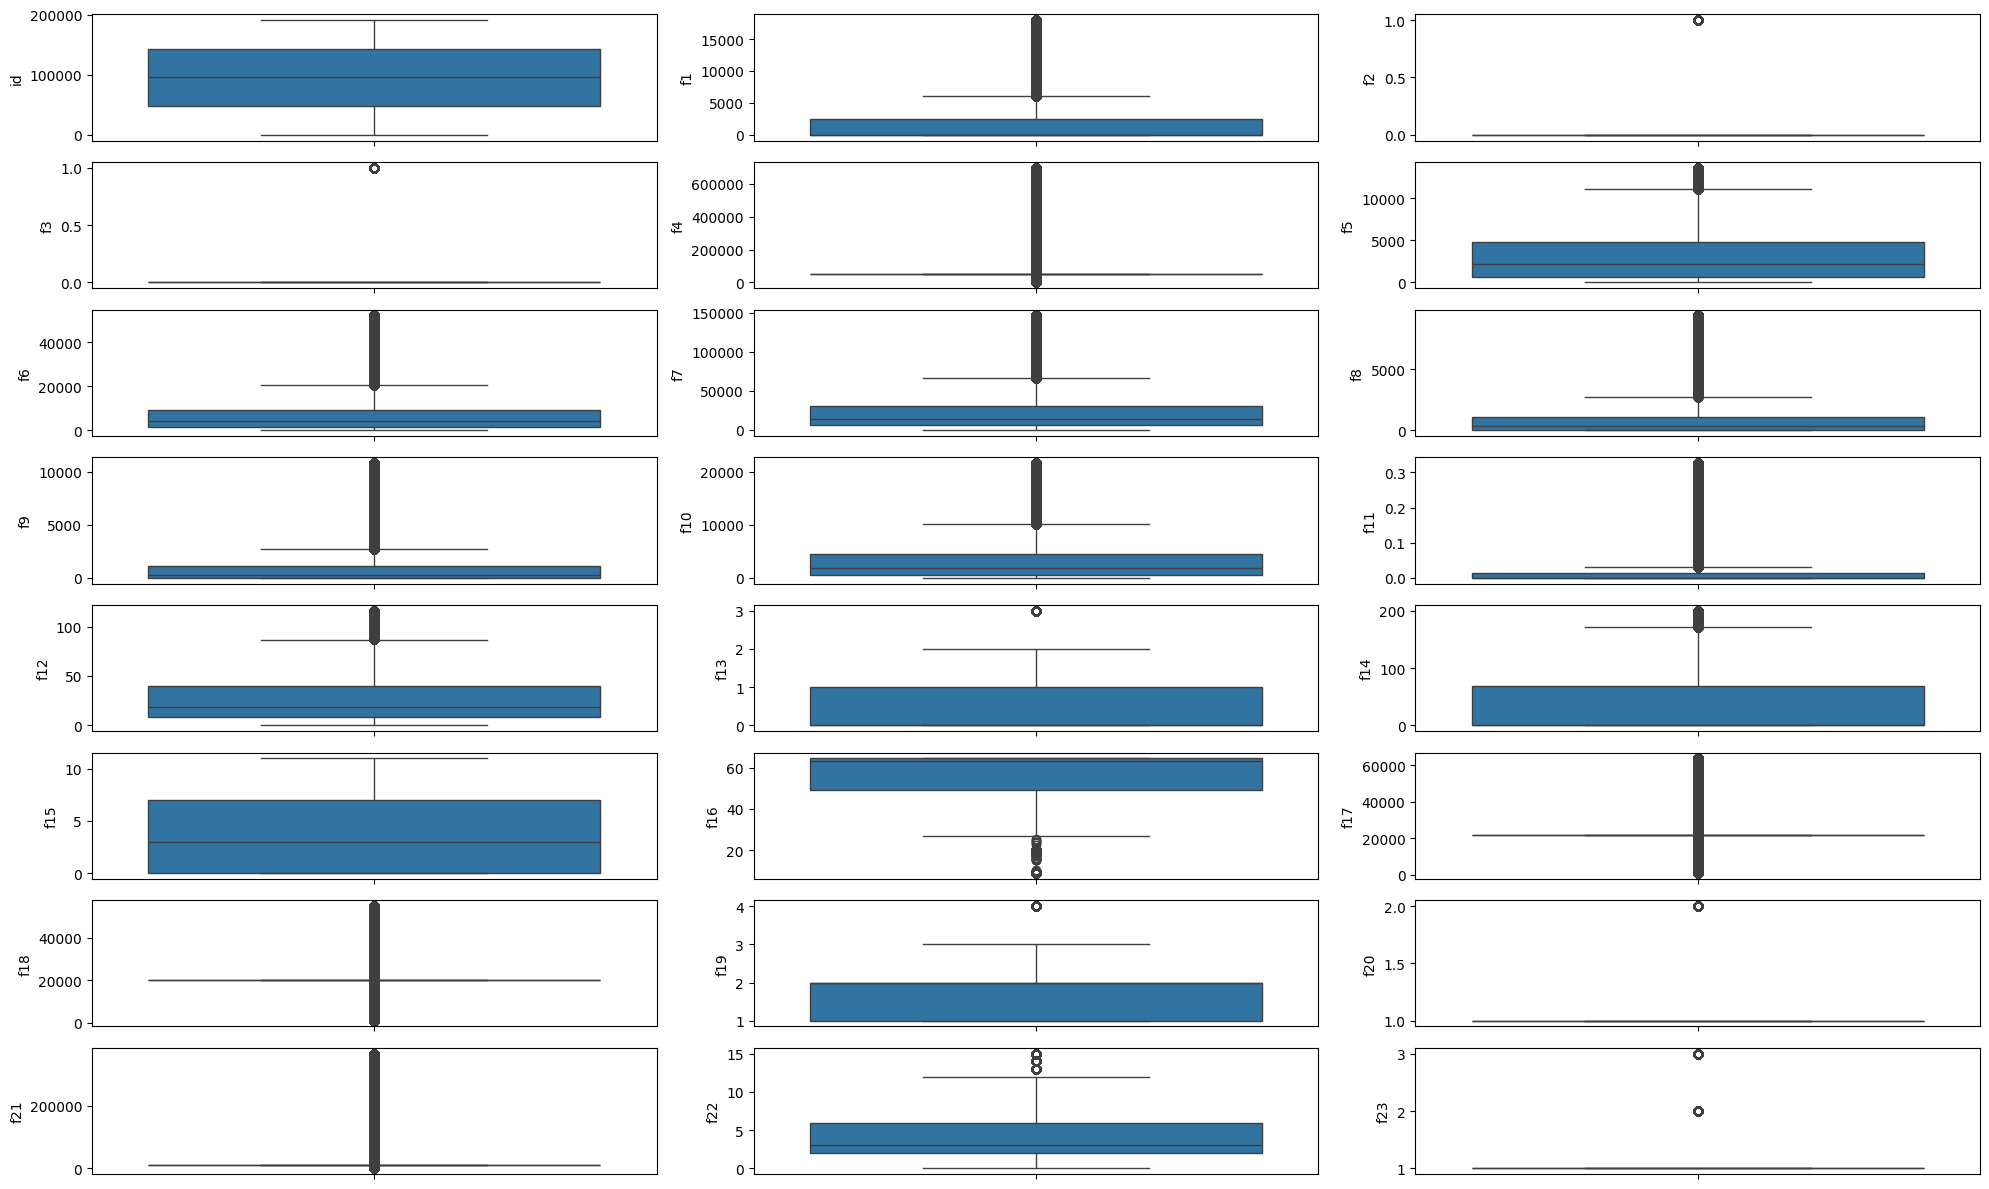

In [12]:
plt.figure(figsize=(20,12))

for i,col in enumerate(num_cols):

    plt.subplot((len(num_cols)+2)//3,3,i+1)

    sns.boxplot(df[col])

plt.tight_layout()

plt.show()

In [13]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

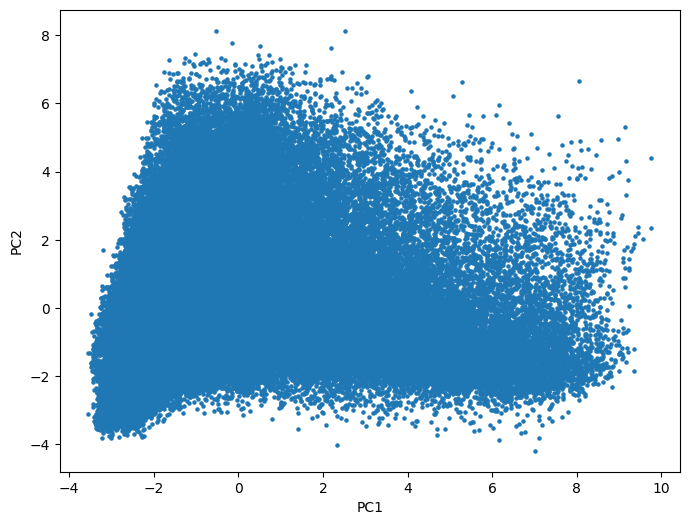

In [14]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    s=5
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

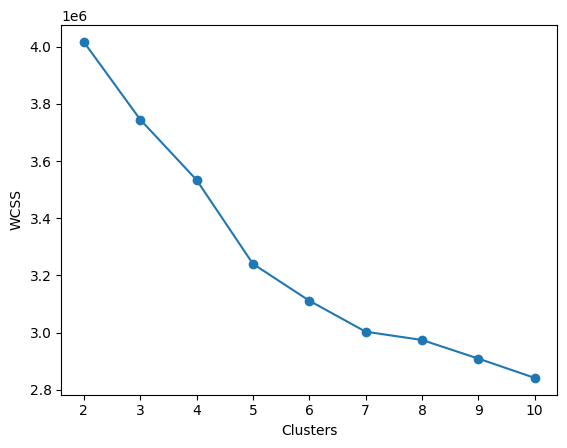

In [15]:
wcss = []

for k in range(2,11):

    km = KMeans(n_clusters=k,random_state=42)

    km.fit(scaled_data)

    wcss.append(km.inertia_)

plt.plot(range(2,11),wcss,marker='o')

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.show()

In [16]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters

In [17]:
df["Cluster"].value_counts()

,count
Cluster,
3,108844
0,29948
1,28564
2,23291


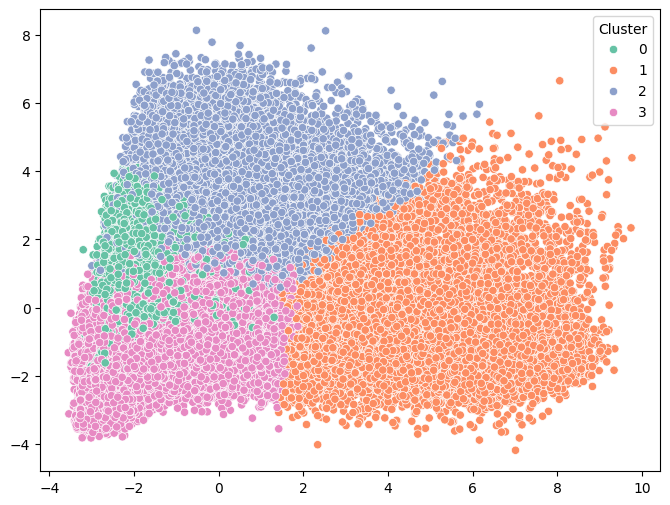

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=df["Cluster"],
    palette="Set2"
)

plt.show()

In [22]:
# ==============================
# Feature Engineering
# ==============================

# Total premium travel spend
df["Travel_Spend"] = (
      df["f6"]
    + df["f9"]
)

# Lifestyle spend
df["Lifestyle_Spend"] = (
      df["f8"]
    + df["f10"]
)

# Benefit utilization
df["Benefit_Usage"] = (
      df["f13"]
    + df["f14"]
    + df["f15"]
    + df["f16"]
)

# Engagement Score
df["Engagement"] = (
      df["f12"]
    + df["f22"]
    + df["f23"]
)

# Product Relationship
df["Relationship"] = (
      df["f19"]
    + df["f20"]
)

# Spend Efficiency
df["Spend_per_Benefit"] = (
    df["f5"] /
    (df["Benefit_Usage"] + 1)
)

# Risk Adjusted Spend
df["Risk_Adjusted_Spend"] = (
    df["f5"] /
    (df["f11"] + 1)
)

# Rewards Burden
df["Reward_Burden"] = (
    df["f21"] /
    (df["f5"] + 1)
)

In [24]:
# ====================================
# Profitability Score
# ====================================

df["Profitability"] = (

      0.35 * df["f5"]          # Total Spend

    + 0.30 * df["f1"]          # Revolve Balance

    + 0.10 * df["Travel_Spend"]

    + 0.05 * df["Relationship"]

    + 0.05 * df["Engagement"]

    + 0.05 * df["Risk_Adjusted_Spend"]

    - 0.20 * df["Benefit_Usage"]

    - 0.10 * df["Reward_Burden"]

    - 0.10 * df["f11"]

    - 0.05 * df["f2"]

    - 0.05 * df["f3"]

)

In [26]:
print(df.columns.tolist())

['id', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'Cluster', 'Travel_Spend', 'Lifestyle_Spend', 'Benefit_Usage', 'Engagement', 'Relationship', 'Spend_per_Benefit', 'Risk_Adjusted_Spend', 'Reward_Burden', 'Profitability']


In [27]:
df["Rank"] = df["Profitability"].rank(
    ascending=False
)

df = df.sort_values(
    "Rank"
)

df.head()

,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,Cluster,Travel_Spend,Lifestyle_Spend,Benefit_Usage,Engagement,Relationship,Spend_per_Benefit,Risk_Adjusted_Spend,Reward_Burden,Profitability,Rank
110337,110337,17967.72633,0.0,0.0,697899.35,13596.2799,52198.432,142299.5374,9419.8740,10828.99400,10702.14750,0.002283,14.0,1.0,0.000,1.0,62.471296,21630.0,19950.0,3.0,2.0,0.000,2.0,1.0,1,63027.42600,20122.02150,64.471296,17.0,5.0,207.667798,13565.304883,0.000000,17118.229221,1.0
77674,77674,17967.72633,0.0,0.0,332025.96,13596.2799,52198.432,146700.5540,2396.8714,10828.99400,21650.58200,0.000317,46.0,1.0,0.000,9.0,63.115330,34320.0,32010.0,2.0,1.0,365166.150,8.0,1.0,1,63027.42600,24047.45340,73.115330,55.0,3.0,183.447606,13591.973963,26.855824,17116.948482,2.0
36697,36697,17967.72633,0.0,0.0,79326.60,13596.2799,52198.432,146700.5540,5099.0616,10720.70406,21434.07618,0.003945,116.0,1.0,10.388,11.0,63.115330,61886.0,15150.0,4.0,2.0,350559.504,14.0,1.0,1,62919.13606,26533.13778,85.503330,131.0,6.0,157.176376,13542.854693,25.781591,17105.242985,3.0
161532,161532,17967.72633,0.0,0.0,312377.94,13596.2799,52198.432,81427.0574,5296.1376,10828.99400,21217.57036,0.053694,19.0,0.0,0.000,7.0,63.115330,38800.0,41600.0,2.0,1.0,0.000,3.0,1.0,1,63027.42600,26513.70796,70.115330,23.0,3.0,191.186343,12903.440011,0.000000,17084.202029,4.0
84919,84919,17967.72633,0.0,0.0,75802.32,13596.2799,52198.432,22064.2422,2498.8800,10504.12418,4491.82350,0.021216,35.0,2.0,0.000,0.0,63.759364,14850.0,14850.0,4.0,2.0,0.000,12.0,1.0,1,62702.55618,6990.70350,65.759364,48.0,6.0,203.661016,13313.817933,0.000000,17074.508384,5.0


In [28]:
top20 = int(len(df)*0.20)

top_customers = df.head(top20)

top_customers.head()

,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,Cluster,Travel_Spend,Lifestyle_Spend,Benefit_Usage,Engagement,Relationship,Spend_per_Benefit,Risk_Adjusted_Spend,Reward_Burden,Profitability,Rank
110337,110337,17967.72633,0.0,0.0,697899.35,13596.2799,52198.432,142299.5374,9419.8740,10828.99400,10702.14750,0.002283,14.0,1.0,0.000,1.0,62.471296,21630.0,19950.0,3.0,2.0,0.000,2.0,1.0,1,63027.42600,20122.02150,64.471296,17.0,5.0,207.667798,13565.304883,0.000000,17118.229221,1.0
77674,77674,17967.72633,0.0,0.0,332025.96,13596.2799,52198.432,146700.5540,2396.8714,10828.99400,21650.58200,0.000317,46.0,1.0,0.000,9.0,63.115330,34320.0,32010.0,2.0,1.0,365166.150,8.0,1.0,1,63027.42600,24047.45340,73.115330,55.0,3.0,183.447606,13591.973963,26.855824,17116.948482,2.0
36697,36697,17967.72633,0.0,0.0,79326.60,13596.2799,52198.432,146700.5540,5099.0616,10720.70406,21434.07618,0.003945,116.0,1.0,10.388,11.0,63.115330,61886.0,15150.0,4.0,2.0,350559.504,14.0,1.0,1,62919.13606,26533.13778,85.503330,131.0,6.0,157.176376,13542.854693,25.781591,17105.242985,3.0
161532,161532,17967.72633,0.0,0.0,312377.94,13596.2799,52198.432,81427.0574,5296.1376,10828.99400,21217.57036,0.053694,19.0,0.0,0.000,7.0,63.115330,38800.0,41600.0,2.0,1.0,0.000,3.0,1.0,1,63027.42600,26513.70796,70.115330,23.0,3.0,191.186343,12903.440011,0.000000,17084.202029,4.0
84919,84919,17967.72633,0.0,0.0,75802.32,13596.2799,52198.432,22064.2422,2498.8800,10504.12418,4491.82350,0.021216,35.0,2.0,0.000,0.0,63.759364,14850.0,14850.0,4.0,2.0,0.000,12.0,1.0,1,62702.55618,6990.70350,65.759364,48.0,6.0,203.661016,13313.817933,0.000000,17074.508384,5.0


In [29]:
top_customers.to_csv(
    "Top20_Customers.csv",
    index=False
)